In [1]:
file='/kaggle/input/datasets/shashk99/offesnsive-data/processed_sold_dataset_v8.csv'
file_original='/kaggle/input/datasets/shashk99/offesnsive-data/sold_train.csv'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import ast

In [3]:
#original dataset
df_org = pd.read_csv(file_original)
df_org.head()
df_org.columns

Index(['post_id', 'text', 'tokens', 'rationales', 'label'], dtype='object')

In [4]:
df = pd.read_csv(file)
# df.drop(columns=['C14',	'C15',	'C16'	,'C17'	,'C18','C19'	,'C20',	'C21'	,'C22'	,'C23'	,'C24'	,'C25'	,'C26'	,'C27'	,'C28'], axis=1, inplace=True)
df.head()
# df.columns


,post_id,text,target_type,target_group,tokens,label,stereotype,category,text_length,off_word_count,rationales,offensive_words,target_type_expanded
0,995411387894542336,තේ නෙවෙයි තෝ බීලා ඉන්නෙ ගිනි වතුර,IND,NaN,"['තේ', 'නෙවෙයි', 'තෝ', 'බීලා', 'ඉන්නෙ', 'ගිනි'...",OFF,0,['Gender'],33,1,"['0', '0', '1', '0', '0', '0', '0']",['තෝ'],no target
1,1128238706303864832,@USER තුනක් ඕනේ නෑ එකක් ගැහුවනම් ඇති ලංකාවට ආප...,UNT,NaN,"['@USER', 'තුනක්', 'ඕනේ', 'නෑ', 'එකක්', 'ගැහුව...",OFF,0,['Gender'],74,1,"['0', '0', '1', '0', '0', '0', '0', '0', '0', ...",['ඕනේ'],no target
2,1290554471714496514,"@USER , @USER @USER ටහුඩු ඒකි තනියම ජීවත් වෙ...",UNT,NaN,"['@USER', ',', '@USER', '@USER', 'ටහුඩු', 'ඒකි...",OFF,0,['Gender'],76,4,"['0', '0', '0', '0', '1', '1', '0', '0', '1', ...","['ටහුඩු', 'ඒකි', 'වෙන්න', 'වෙන්න']",no target
3,909459929446182913,@USER මර්විනුත් මුද්දරයක් වෙයිද දන්නේ නැ,UNT,NaN,"['@USER', 'මර්විනුත්', 'මුද්දරයක්', 'වෙයිද', '...",NOT,0,[],40,0,"['0', '0', '0', '0', '0', '0']",[],no target
4,1305480579375198208,@USER ගොසිප් පීපල් නෙමේ හුත්තො. තෝ වගේ හොරෙක්ට...,UNT,NaN,"['@USER', 'ගොසිප්', 'පීපල්', 'නෙමේ', 'හුත්තො',...",OFF,0,['Gender'],83,3,"['0', '0', '0', '0', '1', '0', '1', '0', '1', ...","['හුත්තො', 'තෝ', 'හොරෙක්ට']",no target


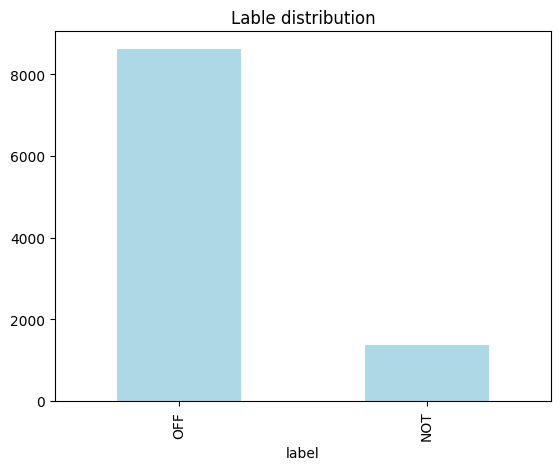

In [5]:
#offensive and non offesnive word count  and distribution

label_counts  =df['label'].value_counts()
label_counts.plot(kind='bar',color='lightblue')

plt.title('Lable distribution')
plt.show()




In [6]:
#separate dataframe for offensive and non-offensive 
off= df['label']=='OFF'  
not_off= df['label']=='NOT' 
df_off=df[off].copy()
df_not_off=df[not_off].copy()
# df_off.head()



In [7]:
#offensive word count
off_words =df_off['offensive_words'].explode()
off_words.value_counts().head(20)

offensive_words
['පට්ට']      125
['යකෝ']       124
['තෝ']        119
['එක']         98
['පිස්සු']     92
['රෙද්ද']      83
['පලයන්']      74
['ටහුඩු']      71
['අයිසෙ']      68
['ඒකි']        66
['අඩො']        63
['කෑල්ල']      63
['කටට']        62
['හෙන']        61
['ගොනා']       58
['උඹ']         58
['මෝඩ']        58
['කැත']        57
['තඩි']        55
['පිස්සා']     55
Name: count, dtype: int64

# **check this : Offensive word count per row ? or somethis else ? what is the purpose ** 

In [8]:
df_off['off_word_count'].value_counts().sort_index()


off_word_count
1     3001
2     2315
3     1447
4      765
5      451
6      258
7      150
8       86
9       62
10      26
11      18
12       9
13      10
14       9
15       2
16       1
17       1
18       1
19       2
23       1
26       1
51       1
66       1
Name: count, dtype: int64

# **why ? shouldn't replce df_off["category"]**

In [9]:
import ast

def clean_column(x):
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)  # string → list
        except:
            return x
    if isinstance(x, list):
        return ", ".join(x) if len(x) > 0 else None
    return x

df_off["category"] = df_off["category"].apply(clean_column)


In [10]:
!apt-get install -y fonts-noto
!cp /usr/share/fonts/truetype/noto/NotoSansSinhala-Regular.ttf /kaggle/working/



Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-noto-cjk fonts-noto-cjk-extra fonts-noto-color-emoji fonts-noto-core
  fonts-noto-extra fonts-noto-ui-core fonts-noto-ui-extra fonts-noto-unhinted
The following NEW packages will be installed:
  fonts-noto fonts-noto-cjk fonts-noto-cjk-extra fonts-noto-color-emoji
  fonts-noto-core fonts-noto-extra fonts-noto-ui-core fonts-noto-ui-extra
  fonts-noto-unhinted
0 upgraded, 9 newly installed, 0 to remove and 72 not upgraded.
Need to get 316 MB of archives.
After this operation, 788 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-core all 20201225-1build1 [12.2 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-noto all 20201225-1build1 [16.8 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-cjk all 1:20220127+repack1-1 [61.2 MB]
Get:4 

In [11]:
import warnings
import matplotlib

# Ignore the specific font warnings
warnings.filterwarnings("ignore", category=UserWarning, module="IPython.core.pylabtools")
warnings.filterwarnings("ignore", message="Glyph.*missing from font")

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
font_path = '/kaggle/working/NotoSansSinhala-Regular.ttf'


if os.path.exists(font_path):
    sinhala_font = fm.FontProperties(fname=font_path)
else:
    sinhala_font = None
    print("Font file not found. Please run: !apt-get install -y fonts-noto-core")
    # !apt-get install -y fonts-noto




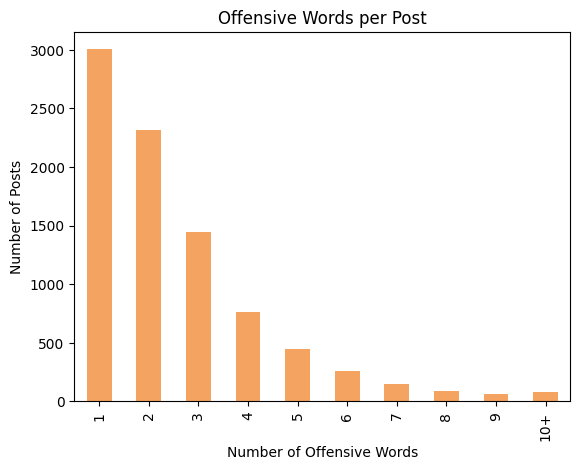

In [12]:
counts = df_off['off_word_count']

# group large values
counts_grouped = counts.apply(lambda x: x if x < 10 else 10)

table = counts_grouped.value_counts().sort_index()

# rename last category
table.index = [str(i) if i < 10 else "10+" for i in table.index]


table.plot(kind='bar', color='sandybrown')

plt.title("Offensive Words per Post")
plt.xlabel("Number of Offensive Words")
plt.ylabel("Number of Posts")
plt.show()


In [13]:
off_words_cleaned = off_words.astype(str).str.strip("[]' ")

# 2. Now get the top 20
top_off_words = off_words_cleaned.value_counts().head(20)



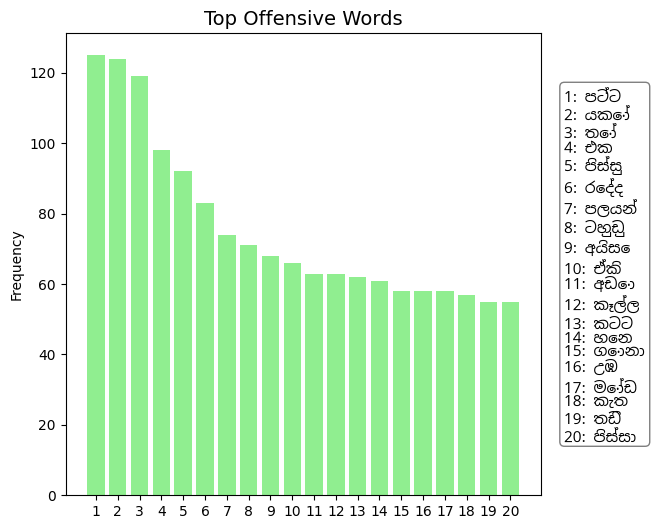

In [14]:

labels = [str(x) for x in top_off_words.index]
counts = top_off_words.values
x_indexes = range(len(labels))

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x_indexes, counts, color='lightgreen' )

ax.set_xticks(x_indexes)
ax.set_xticklabels([i+1 for i in x_indexes])

plt.title("Top Offensive Words", fontsize=14, )
plt.ylabel("Frequency")

label_text = "\n".join([f"{i+1}: {label}" for i, label in enumerate(labels)])

plt.text(1.05, 0.5, label_text, 
         transform=ax.transAxes, 
         fontsize=11, 
         verticalalignment='center', 
         fontproperties=sinhala_font,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.subplots_adjust(right=0.6) 
plt.show()

# **Catagories** 
##  Combined categories 

Category counts:
category
Gender                      7437
Disability, Gender           676
Disability                   200
Age, Gender                  176
Race, Gender                  18
Age                           17
Disability, Age, Gender       10
Age, Disability, Gender        7
Age, Disability                3
Disability, Race, Gender       1
Race                           1
Disability, Age                1
Name: count, dtype: int64


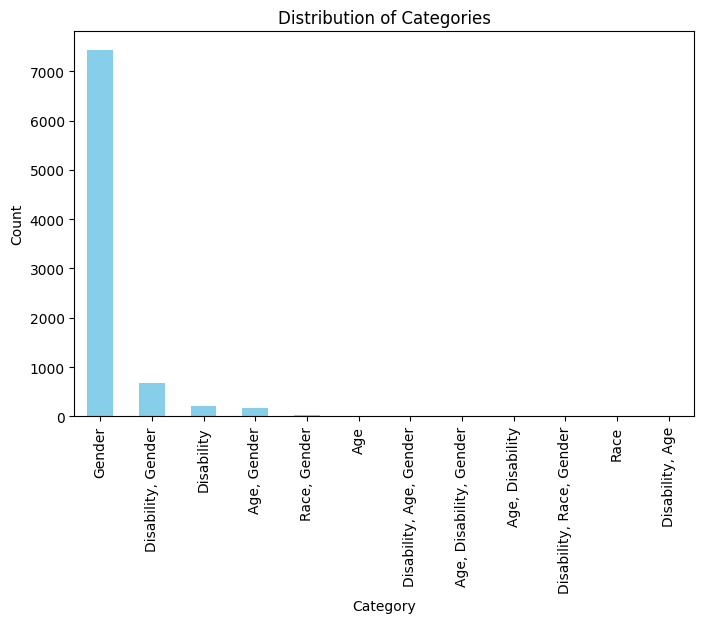

In [15]:
print("Category counts:")
print(df_off["category"].value_counts())

plt.figure(figsize=(8,5))
df_off["category"].value_counts().plot(kind="bar", color="skyblue")
plt.title("Distribution of Categories")
plt.ylabel("Count")
plt.xlabel("Category")
plt.show()


## single categories 

In [16]:
df_off["category_updated"] = df_off["category"].str.split(",")

df_off_exploded = df_off.explode("category_updated")

# Clean spaces
df_off_exploded["category_updated"] = df_off_exploded["category_updated"].str.strip()

# Count SINGLE categories
counts = df_off_exploded["category_updated"].value_counts()

print(counts)


category_updated
Gender        8325
Disability     898
Age            214
Race            20
Name: count, dtype: int64


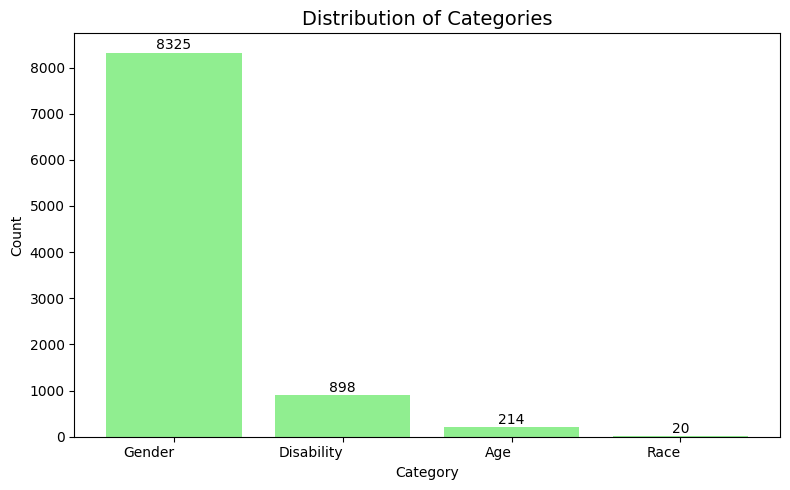

In [17]:
fig, ax = plt.subplots(figsize=(8,5))

# Plot bars
bars = ax.bar(counts.index, counts.values, color='lightgreen')

# Add count labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x-position: center of bar
        height + 5,                         # y-position: a bit above bar
        f'{int(height)}',                    # label text
        ha='center', va='bottom', fontsize=10
    )

# Titles and labels
ax.set_title("Distribution of Categories", fontsize=14)
ax.set_ylabel("Count")
ax.set_xlabel("Category")
plt.xticks(rotation=360, ha='right')
plt.tight_layout()
plt.show()


### **Sentence Length Analysis** 

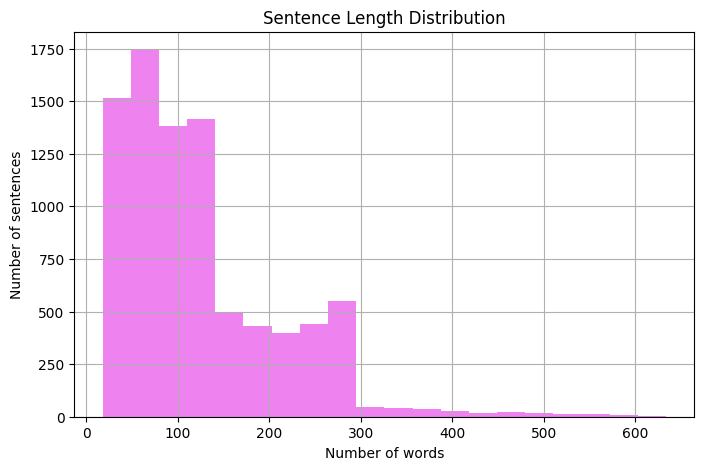

In [18]:
# Sentence Length Analysis

plt.figure(figsize=(8,5))
df_off["text_length"].hist(bins=20, color="violet")
plt.title("Sentence Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Number of sentences")
plt.show()

### Mean sentence length per category

In [19]:
# Mean sentence length per category
print("\nMean sentence length per category:")
print(df_off.groupby("category")["text_length"].mean())


Mean sentence length per category:
category
Age                         111.764706
Age, Disability             162.333333
Age, Disability, Gender     228.857143
Age, Gender                 168.818182
Disability                  103.710000
Disability, Age             115.000000
Disability, Age, Gender     223.100000
Disability, Gender          160.730769
Disability, Race, Gender    190.000000
Gender                      121.501681
Race                         40.000000
Race, Gender                157.611111
Name: text_length, dtype: float64


### Class Imbalance Check

In [20]:
# Class Imbalance Check
print("\nNormalized class distribution:")
print(df_off["category"].value_counts(normalize=True))


Normalized class distribution:
category
Gender                      0.870130
Disability, Gender          0.079092
Disability                  0.023400
Age, Gender                 0.020592
Race, Gender                0.002106
Age                         0.001989
Disability, Age, Gender     0.001170
Age, Disability, Gender     0.000819
Age, Disability             0.000351
Disability, Race, Gender    0.000117
Race                        0.000117
Disability, Age             0.000117
Name: proportion, dtype: float64


## Similarity of Target Group Attributes Based on Hate Spans

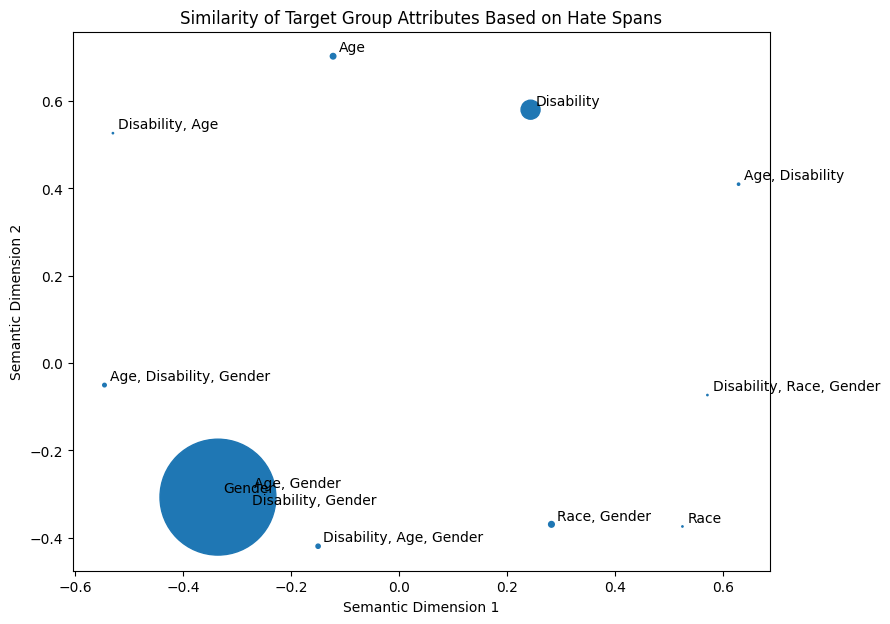

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_distances
from sklearn.manifold import MDS

# Visualize similarity between target group attributes based on the language used in offensive spans
category_texts = (
    df_off
    .dropna(subset=["offensive_words"])
    .groupby("category")["offensive_words"]
    .apply(lambda x: " ".join(x.astype(str)))
)

categories = category_texts.index
texts = category_texts.values

proportions = df_off["category"].value_counts(normalize=True).reindex(categories)

vectorizer = TfidfVectorizer(
    stop_words="english",
    min_df=2
)

X = vectorizer.fit_transform(texts)

dist = cosine_distances(X)

mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords = mds.fit_transform(dist)

plt.figure(figsize=(9,7))

plt.scatter(
    coords[:,0],
    coords[:,1],
    s=proportions.values * 8000
)

for i, label in enumerate(categories):
    plt.text(coords[i,0]+0.01, coords[i,1]+0.01, label, fontsize=10)

plt.title("Similarity of Target Group Attributes Based on Hate Spans")
plt.xlabel("Semantic Dimension 1")
plt.ylabel("Semantic Dimension 2")

plt.show()

### Boxplot of sentence length grouped by offensiveness label

<Axes: title={'center': 'text_length'}, xlabel='label'>

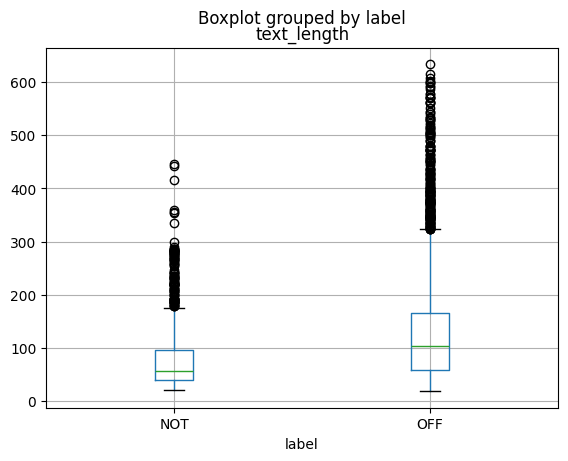

In [22]:
# Boxplot of sentence length grouped by offensiveness label


df.boxplot(column="text_length", by="label")

#  Additonal steps 

## Analysis words and offensiveness 

In [23]:
file2='/kaggle/input/datasets/shashk99/offesnsive-data/sinhala_offensive_language_dataset.csv'

In [24]:
df = pd.read_csv(file2)
# df.drop(columns=['C14',	'C15',	'C16'	,'C17'	,'C18','C19'	,'C20',	'C21'	,'C22'	,'C23'	,'C24'	,'C25'	,'C26'	,'C27'	,'C28'], axis=1, inplace=True)
df.head()

,id,word,category,offensiveness_level,language
0,1,මෝඩ,insult,medium,si
1,2,පිස්සු,insult,medium,si
2,3,ගොන්,insult,medium,si
3,4,බූරු,insult,medium,si
4,5,කුණු,insult,medium,si
